**Module 1**

---

**Activity 1**

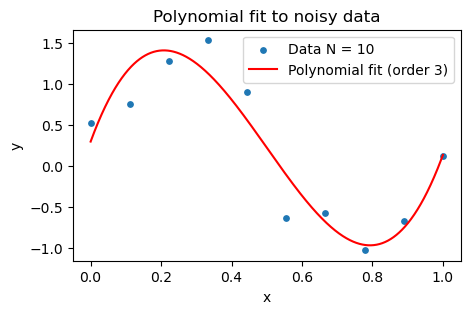

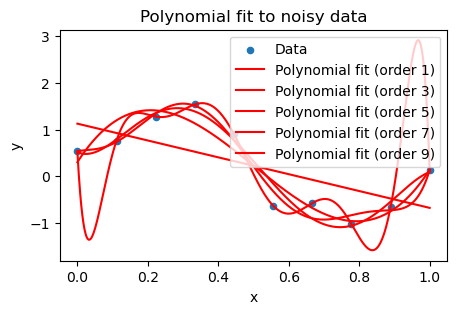

In [135]:
import numpy as np
import matplotlib.pyplot as plt
import time

N=10

# Set random seed for reproducibility (optional)
np.random.seed(0)

sigma = 0.3

def generate_data(N):
    x = np.linspace(0, 1, N)
    noise = np.random.normal(0, sigma, N)
    y = np.sin(2 * np.pi*x) + noise
    return x, y

x, y = generate_data(N)


order = 3
# Fit polynomial
coeffs = np.polyfit(x, y, order)
poly = np.poly1d(coeffs)

x_fit = np.linspace(0, 1, 1000)
y_fit = poly(x_fit)

plt.figure(figsize=(5, 3))
plt.scatter(x, y, s=15, label=f"Data N = {N}")
plt.plot(x_fit, y_fit, 'r', label=f"Polynomial fit (order {order})")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Polynomial fit to noisy data")
plt.show()


plt.figure(figsize=(5, 3))
plt.scatter(x, y, s=20, label="Data")

# Loop over polynomial orders
for order in range(1, 10, 2):
    coeffs = np.polyfit(x, y, order)
    poly = np.poly1d(coeffs)
    x_fit = np.linspace(0, 1, 1000)
    y_fit = poly(x_fit)

    plt.plot(x_fit, y_fit, 'r', label=f"Polynomial fit (order {order})")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Polynomial fit to noisy data")
plt.show()


In [174]:
N = 1000
x, y = generate_data(N)

order = 9
coeffs = np.polyfit(x, y, order)
poly = np.poly1d(coeffs)

sse = np.sum((y - poly(x))**2)

Erms = np.sqrt(sse/N) 

print("SSE =", sse)
print("Erms =", Erms)


SSE = 91.28479128823699
Erms = 0.30213373080183714


**Analysis 1b**

$\sigma = 0.3$

$E_{rms}=0.302$




**Analysis 1c**

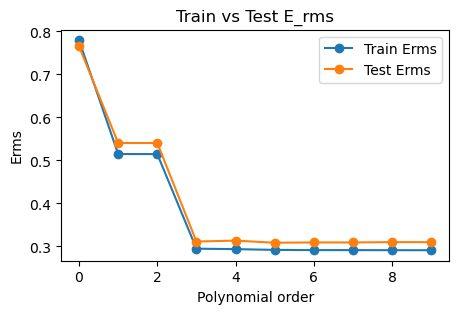

In [175]:
perm = np.random.permutation(N)
split = N // 4   # 1/4

# Test (3/4) and Train (1/4)
test_idx = perm[split:]
train_idx = perm[:split]
x_test, y_test = x[test_idx], y[test_idx]
x_train, y_train = x[train_idx], y[train_idx]

# -----------------------------
# RMSE vs polynomial order
# -----------------------------
orders = range(10)
rmse_train = []
rmse_test = []

for order in orders:
    # Fit polynomial on training set
    coeffs = np.polyfit(x_train, y_train, order)
    poly = np.poly1d(coeffs)

    # Predictions
    y_train_pred = poly(x_train)
    y_test_pred = poly(x_test)

    # RMSE
    rmse_train.append(np.sqrt(np.mean((y_train - y_train_pred)**2)))
    rmse_test.append(np.sqrt(np.mean((y_test - y_test_pred)**2)))

plt.figure(figsize=(5, 3))
plt.plot(orders, rmse_train, marker='o', label='Train Erms')
plt.plot(orders, rmse_test, marker='o', label='Test Erms')
plt.xlabel("Polynomial order")
plt.ylabel("Erms")
plt.title("Train vs Test E_rms")
plt.legend()
plt.show()

**Activity 2**

---

## Vandermonde Matrix and Polynomial Regression

### 1. Vandermonde (Design) Matrix

Given training data:
$$
x_{\text{train}} = [x_0, x_1, \dots, x_{M-1}]
$$

and a desired polynomial degree `order = N`, the **design matrix** \(X\) is a Vandermonde matrix defined as:
$$
X =
\begin{bmatrix}
1 & x_0 & x_0^2 & \dots & x_0^N \\
1 & x_1 & x_1^2 & \dots & x_1^N \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_{M-1} & x_{M-1}^2 & \dots & x_{M-1}^N
\end{bmatrix} \in \mathbb{R}^{M \times {N+1}}
$$


### 2. Polynomial Regression

Polynomial regression fits a polynomial function:
$$
y \approx \beta_0 + \beta_1 x + \beta_2 x^2 + \dots + \beta_9 x^N
$$

We compute the coefficients **β** using the least squares method:
$$
\boldsymbol{\beta} = (X^T X)^{-1} X^T \mathbf{y}
$$

Where:
- $X \in \mathbb{R}^{M \times N+1}$ is the design matrix  
- $\mathbf{y} \in \mathbb{R}^{M}$ is the vector of target values  
- $\boldsymbol{\beta} \in \mathbb{R}^{N+1}$ are the polynomial coefficients

This solution finds the polynomial that **minimizes the sum of squared errors (SSE)**:

$$
\text{SSE} = \sum_{i=0}^{M-1} \left( y_i - \sum_{j=0}^{9} \beta_j x_i^j \right)^2
$$


### 3. Making Predictions
For new input values $x_{\text{new}}$, the predicted values are computed as:
$$
y_{\text{pred}} = \beta_0 + \beta_1 x_{\text{new}} + \dots + \beta_{N} x_{\text{new}}^{N}
$$

Or equivalently, in **matrix form**:
$$
y_{\text{pred}} = X_{\text{new}} \, \boldsymbol{\beta}, \quad
X_{\text{new}} = \text{Vandermonde matrix of } x_{\text{new}}
$$


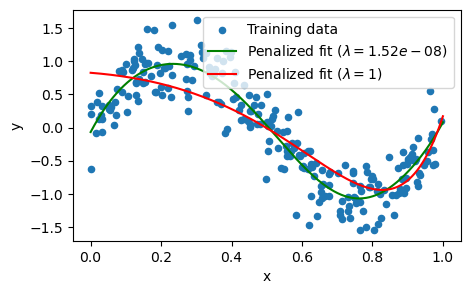

In [176]:
def ridge_poly_fit(x_train, y_train, order, lam):
    """
    Fit a polynomial of given order using ridge regression.

    Parameters
    ----------
    x_train : array-like, shape (N,)
    y_train : array-like, shape (N,)
    order   : int, polynomial degree
    lam     : float, regularization strength (lambda)

    Returns
    -------
    coeffs : ndarray
        Coefficients [w0, w1, ..., w_order] (constant → highest power)
    poly : np.poly1d
        Polynomial object representing the fitted ridge model
    """

    # Vandermonde matrix: [1, x, x^2, ..., x^order]
    X = np.vander(x_train, order + 1, increasing=True)
    # columns: [1, x, x^2, ..., x^9]

    # Ridge penalty matrix (do NOT penalize constant term)
    L = np.eye(order + 1)
    L[0, 0] = 0   # no penalty on intercept

    # Solve normal equations
    if lam == 0:
        # Closed-form ridge solution
        coeffs = np.linalg.solve(X.T @ X, X.T @ y_train)
    else:
        coeffs = np.linalg.solve(X.T @ X + lam * L, X.T @ y_train)

    return coeffs

order = 9
lam1 = np.exp(-18)  # regularization strength
lam2 = np.exp(0)

coeffs_ridge1 = ridge_poly_fit(x_train, y_train, order, lam1)
coeffs_ridge2 = ridge_poly_fit(x_train, y_train, order, lam2)
# Build polynomial from ridge coefficients
poly_ridge1 = np.poly1d(coeffs_ridge1[::-1]) # reverse list because np.poly1d expects highest power first
poly_ridge2 = np.poly1d(coeffs_ridge2[::-1])

# Smooth x for plotting
x_fit = np.linspace(0, 1, 1000)
y_fit1 = poly_ridge1(x_fit)
y_fit2 = poly_ridge2(x_fit)

# Plot
plt.figure(figsize=(5, 3))
plt.scatter(x_train, y_train, s=20, label="Training data")
plt.plot(x_fit, y_fit1,'g', label=f"Penalized fit ($\\lambda = {lam1:.3g}$)")
plt.plot(x_fit, y_fit2,'r', label=f"Penalized fit ($\\lambda = {lam2:.3g}$)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


# y_train_pred = poly_ridge(x_train)
# y_test_pred = poly_ridge(x_test)
# print(f"Shape\n y_train_pred { y_train_pred.shape}\n y_test_pred {y_test_pred.shape}")

# SSE
sse = np.sum((y_train - poly_ridge(x_train))**2)
# L2 penalty (exclude constant term)
penalty = lam * np.sum(coeffs_ridge[1:]**2)
sse_pen = sse + penalty


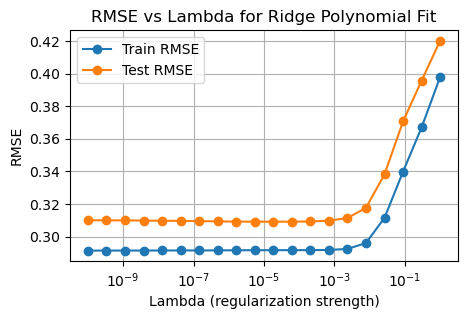

In [177]:
# order = 9  # polynomial order
lambdas = np.logspace(-10, 0, 20)  # lambda values from 1e-4 to 10
rmse_train = []
rmse_test = []

# Design matrices for train and test
X_train = np.vander(x_train, order + 1, increasing=True)
X_test  = np.vander(x_test, order + 1, increasing=True)

for lam in lambdas:
    coeffs_ridge = ridge_poly_fit(x_train, y_train, order, lam)
    
    # Predictions
    y_train_pred = X_train @ coeffs_ridge
    y_test_pred  = X_test @ coeffs_ridge

    # Compute RMSE
    rmse_train.append(np.sqrt(np.mean((y_train - y_train_pred)**2)))
    rmse_test.append(np.sqrt(np.mean((y_test - y_test_pred)**2)))

plt.figure(figsize=(5,3))
plt.semilogx(lambdas, rmse_train, marker='o', label='Train RMSE')
plt.semilogx(lambdas, rmse_test, marker='o', label='Test RMSE')
plt.xlabel("Lambda (regularization strength)")
plt.ylabel("RMSE")
plt.title("RMSE vs Lambda for Ridge Polynomial Fit")
plt.legend()
plt.grid()
plt.show()


## Bayesian Model Setup

We model the data using a **9th-order polynomial**, written in vector form as

$$
f(x,\mathbf{w}) = \sum_{i=0}^{9} w_i x^i = \mathbf{w}^T \boldsymbol{\phi}(x)
$$

where the **basis function vector** is
$$
\boldsymbol{\phi}(x) = [1, x, x^2, ..., x^9]^T
$$

and the weight vector is
$$
\mathbf{w} = [w_0, w_1, ..., w_9]^T.
$$

### **Prior on Weights**

We place a Gaussian prior over the polynomial coefficients:
$$
p(\mathbf{w}|\alpha) = \mathcal{N}_{10}(\mathbf{w}|\mathbf{0}, \alpha^{-1} I)
$$

where:
- $\alpha$ = prior precision (controls how large weights can be)
- $\alpha$ controls **model smoothness / regularization** (how large weights can be)
- $\mathcal{N}_{10}$ = 10-variate normal distribution

### **Likelihood (Noise Model)**

We assume noisy observations with Gaussian noise:
$$
y = \mathbf{w}^T \boldsymbol{\phi}(x) + \mathcal{N}(0, \beta^{-1} I)
$$

so the likelihood function
$$
p(\mathbf{y}|\mathbf{x},\mathbf{w},\beta) = \mathcal{N}_{10}(\mathbf{y}|f(\mathbf{x},\mathbf{w}), \beta^{-1} I)
$$

where:
- $\beta$ = noise precision
- $\beta^{-1}$ = $\sigma^2$ = noise variance
- $\beta$ controls **assumed noise level**  

### **Posterior Over Weights**

Using Bayes' theorem:
$$
p(\mathbf{w}|\mathbf{x},\mathbf{y},\beta) = \mathcal{N}(\mathbf{m}_N, S_N)
$$

where
$$
S_N = (\alpha I + \beta X^T X)^{-1}
$$

$$
\mathbf{m}_N = \beta S_N X^T \mathbf{y}
$$

$$
X =
\begin{bmatrix}
1 & x_0 & x_0^2 & \dots & x_0^9 \\
1 & x_1 & x_1^2 & \dots & x_1^9 \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_{M-1} & x_{M-1}^2 & \dots & x_{M-1}^9
\end{bmatrix}
$$

- $\mathbf{m}_N$ = posterior mean of weights  
- $S_N$ = posterior covariance
- $X$ = design matrix

### **Predictive Distribution**

For a new input $x_*$:
$$
p(y_*|x_*, \mathbf{x},\mathbf{y}) = \mathcal{N}(y_*|\mu(x_*), \sigma^2(x_*))
$$

where
$$
\mu(x_*) = \boldsymbol{\phi}(x_*)^T \mathbf{m}_N
$$

$$
\sigma^2(x_*) = \beta^{-1} + \boldsymbol{\phi}(x_*)^T S_N \boldsymbol{\phi}(x_*)
$$

- $\mu(x_*)$ : predictive mean
- $\sigma^2(x_*)$ : predictive variance

The model returns both a **best-fit curve** and **uncertainty at every** x


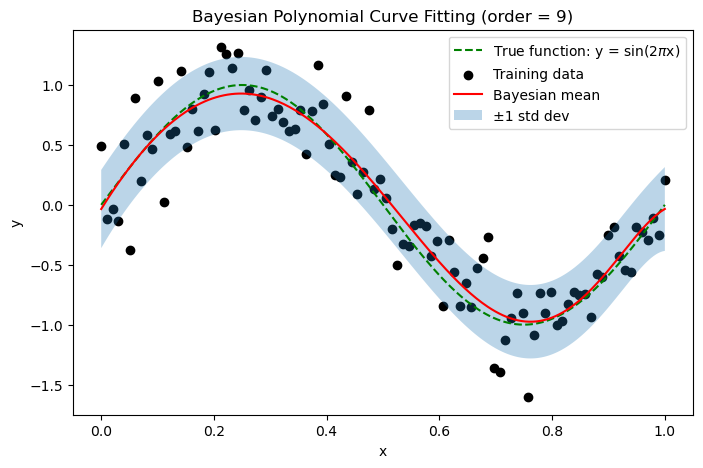

In [197]:
# -------------------------------
# Generate noisy sine data
# -------------------------------
np.random.seed(1)

order = 9
noise_std = 0.3

x_train, y_train = generate_data(100)
X_train = np.vander(x_train, order + 1, increasing=True)

# -------------------------------
# Set Bayesian hyperparameters
# -------------------------------
alpha = 5e-3                # prior precision (small -> flexible weights)
beta  = 1 / noise_std**2    # noise precision

# -------------------------------
# Compute posterior over weights
# -------------------------------
I = np.eye(order+1)

S_N = np.linalg.inv(alpha * I + beta * X_train.T @ X_train)
m_N = beta * S_N @ X_train.T @ y_train

# -------------------------------
# Make predictions with uncertainty
# -------------------------------
x_test, y_test = generate_data(300)
X_test = np.vander(x_test, order + 1, increasing=True)

# Predictive mean
y_mean = X_test @ m_N

# Predictive variance
y_var = 1/beta + np.sum(X_test @ S_N * X_test, axis=1)
y_std = np.sqrt(y_var)

# -------------------------------
# Plot results
# -------------------------------
plt.figure(figsize=(8,5))

# True function
true_func = lambda x: np.sin(2 * np.pi * x)
plt.plot(x_test, true_func(x_test), 'g--', label="True function: y = sin(2$\pi$x)")

# Training data
plt.scatter(x_train, y_train, color='black', label="Training data")

# Posterior mean
plt.plot(x_test, y_mean, 'r', label="Bayesian mean")

# Uncertainty band
plt.fill_between(x_test,
                 y_mean - 1*y_std,
                 y_mean + 1*y_std,
                 alpha=0.3, # this controls how see-through the shaded region
                 label="±1 std dev")

plt.legend()
plt.title("Bayesian Polynomial Curve Fitting (order = 9)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()
